Correlation Matrix used for feature selction

First building a pairwise correlation matrix between features, to find out which features are redundant indicators that carry the same information

Importing all the necessary libraries

In [10]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import mutual_info_regression

import ta
from ta.trend import SMAIndicator, EMAIndicator, MACD, ADXIndicator, AroonIndicator, KSTIndicator
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator, WilliamsRIndicator
from ta.volatility import BollingerBands, AverageTrueRange, KeltnerChannel
from ta.volume import OnBalanceVolumeIndicator, AccDistIndexIndicator 

import seaborn as sns
import matplotlib.pyplot as plt


Loading roughly the last 10 years of APPL OHLCV data from CSV file (downloaded from Market Data API). 
Start Date: 2015-01-01, End Date: 2026-01-08. 

Ajusting my data as Apple stock split four-for-one on 31st August 2020

Calculating correlation is deterministic so seeing the code to remove randomness is not needed here.

In [ ]:
#Loading the OHLCV data CSV file into a dataframe 
data = pd.read_csv("AAPL_15min_OHLCV.csv")

#Converts the timestamp column into a proper datetime object, which is easier for manipulation later on
data['timestamp'] = pd.to_datetime(data['timestamp'])

SPLIT_DATE = pd.Timestamp("2020-08-31")
SPLIT_RATIO = 4.0

# 3. Get the last bar BEFORE the split and the first bar ON/AFTER the split
pre_split_bar = data[data['timestamp'] < SPLIT_DATE].iloc[-1]
post_split_bar = data[data['timestamp'] >= SPLIT_DATE].iloc[0]

pre_split_mask = data['timestamp'] < SPLIT_DATE

# Adjust prices - divide all the values listed below by 4
price_cols = ['open', 'high', 'low', 'close']
data.loc[pre_split_mask, price_cols] /= SPLIT_RATIO

# Adjust volume - multiply the volume by 4
data.loc[pre_split_mask, 'volume'] *= SPLIT_RATIO

print("--- Verification Check: Aug 31, 2020 Split ---")
print(f"Last Price (Pre-Split):  ${pre_split_bar['close']:.2f} at {pre_split_bar['timestamp']}")
print(f"First Price (Post-Split): ${post_split_bar['close']:.2f} at {post_split_bar['timestamp']}")

#data.to_csv("AfterSplitFix.csv", index=False)



--- Verification Check: Aug 31, 2020 Split ---
Last Price (Pre-Split):  $498.90 at 2020-08-28 19:45:00
First Price (Post-Split): $128.35 at 2020-08-31 13:30:00


Feature Engineering

In [8]:
#Define windows to test:
sma_windows = [13, 26, 78]     # half-day, 1-day, 3-day
ema_windows = [13, 26, 78]
fwma_windows = [13, 26]
aroon_windows = [26, 52] 

# Momentum
rsi_windows = [14, 26]       

# Rate of change
roc_windows = [13, 26, 78]
vol_roc_windows = [26, 78]

#Normalising features do not output different results from the correlation matrix
feature_cols = []

# --- Trend Indicators ---

for w in sma_windows:
    col = f'sma_{w}'
    sma = SMAIndicator(data['close'], window=w).sma_indicator()
    data[col] = data['close'] / sma
    feature_cols.append(col)

for w in ema_windows:
    col = f'ema_{w}'
    ema = EMAIndicator(data['close'], window=w).ema_indicator()
    data[col] = data['close'] / ema
    feature_cols.append(col)

macd = MACD(data['close'])
data['macd'] = macd.macd() / data['close']
data['macd_signal'] = macd.macd_signal() / data['close']
feature_cols += ['macd', 'macd_signal']

data['adx_26'] = ADXIndicator(data['high'], data['low'], data['close'], window=26).adx()
feature_cols.append('adx_26')

def fibonacci_weights(n):
    if n == 1:
        return np.array([1.0])
    
    fib = [1, 2] 
    while len(fib) < n:
        fib.append(fib[-1] + fib[-2])
    
    weights = np.array(fib)
    return weights / weights.sum()

for w in fwma_windows:
    weights = fibonacci_weights(w)
    fwma = data['close'].rolling(w).apply(lambda x: np.dot(x, weights), raw=True)
    col = f'fwma_{w}'
    data[col] = data['close'] / fwma
    feature_cols.append(col)


for w in aroon_windows:
    aroon = AroonIndicator(high=data['high'], low=data['low'], window=w)

    up_col = f'aroon_up_{w}'
    down_col = f'aroon_down_{w}'

    data[up_col] = aroon.aroon_up()
    data[down_col] = aroon.aroon_down()

    feature_cols += [up_col, down_col]

# --- Momentum Indicators ---

for w in rsi_windows:
    col = f'rsi_{w}'
    data[col] = RSIIndicator(data['close'], window=w).rsi()
    feature_cols.append(col)
    
stoch = StochasticOscillator(data['high'], data['low'], data['close'], window=14, smooth_window=3)
data['stoch_14'] = stoch.stoch()
feature_cols.append('stoch_14')

for w in roc_windows:
    col = f'roc_{w}'
    data[col] = ROCIndicator(data['close'], window=w).roc()
    feature_cols.append(col)

data['williams_r'] = WilliamsRIndicator(
    data['high'], data['low'], data['close'], lbp=14
).williams_r()
feature_cols.append('williams_r')

kst = KSTIndicator(
    close=data['close'],
    roc1=10, roc2=15, roc3=20, roc4=30,
    window1=10, window2=10, window3=10, window4=15
)

# The 'diff' helps the LSTM see when momentum is accelerating or decelerating
data['kst_diff'] = (kst.kst() - kst.kst_sig()) / data['close'] 

feature_cols += ['kst_diff']

# --- Volatility Indicators ---
    
atr_val = AverageTrueRange(data['high'], data['low'], data['close'], window=26).average_true_range()
data['atr_26'] = atr_val / data['close']
feature_cols.append('atr_26')

bb = BollingerBands(data['close'], window=26, window_dev=2)
data['bb_width'] = bb.bollinger_wband()
feature_cols.append('bb_width')

# Garman–Klass volatility (~1 session)
mask = (data[['open','high','low','close']] > 0).all(axis=1)

log_hl = np.log(data.loc[mask, 'high'] / data.loc[mask, 'low'])
log_co = np.log(data.loc[mask, 'close'] / data.loc[mask, 'open'])

rs = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
data.loc[mask, 'GK_vol_session'] = np.sqrt(rs.rolling(26).mean())
feature_cols.append('GK_vol_session')

# --- Volume Indicators ---

data['obv_diff'] = OnBalanceVolumeIndicator(data['close'], data['volume']).on_balance_volume().diff().fillna(0)
data['acc_dist_diff'] = AccDistIndexIndicator(data['high'], data['low'], data['close'], data['volume']).acc_dist_index().diff().fillna(0)
feature_cols += ['obv_diff', 'acc_dist_diff']

for w in vol_roc_windows:
    col = f'vol_roc_{w}'
    data[col] = ROCIndicator(data['volume'], window=w).roc()
    feature_cols.append(col)

kc = KeltnerChannel(
    high=data['high'],
    low=data['low'],
    close=data['close'],
    window=20,
    window_atr=10
)

data['keltner_width'] = (
    kc.keltner_channel_hband() -
    kc.keltner_channel_lband()
) / data['close']

feature_cols.append('keltner_width')

data['target'] = data['close'].shift(-1)

#data.to_csv("Before.csv", index=False)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data.to_csv("After.csv", index=False)

X = data[feature_cols].astype(np.float32)
print(X.head())

y = data['target'].astype(np.float32)

      sma_13    sma_26    sma_78    ema_13    ema_26    ema_78      macd  \
78  0.994829  0.994367  0.987410  0.994120  0.992907  0.988027 -0.001254   
79  0.987434  0.986901  0.979635  0.987958  0.985889  0.980435 -0.002303   
80  0.989979  0.989469  0.981751  0.991316  0.988702  0.982784 -0.002929   
81  0.994406  0.994370  0.986285  0.996330  0.993604  0.987473 -0.003022   
82  0.995125  0.995211  0.986948  0.997241  0.994493  0.988224 -0.003033   

    macd_signal     adx_26   fwma_13  ...  williams_r  kst_diff    atr_26  \
78    -0.001817  27.286209  0.994636  ...  -87.820511  0.182501  0.005452   
79    -0.001926  27.651718  0.991616  ...  -98.260872  0.146903  0.005663   
80    -0.002124  28.079185  0.996008  ...  -81.349205  0.103301  0.005659   
81    -0.002296  28.048790  1.000269  ...  -62.301586  0.072051  0.005694   
82    -0.002442  27.978489  1.000450  ...  -60.345238  0.048767  0.005664   

    bb_width  GK_vol_session    obv_diff  acc_dist_diff  vol_roc_26  \
78  1.416

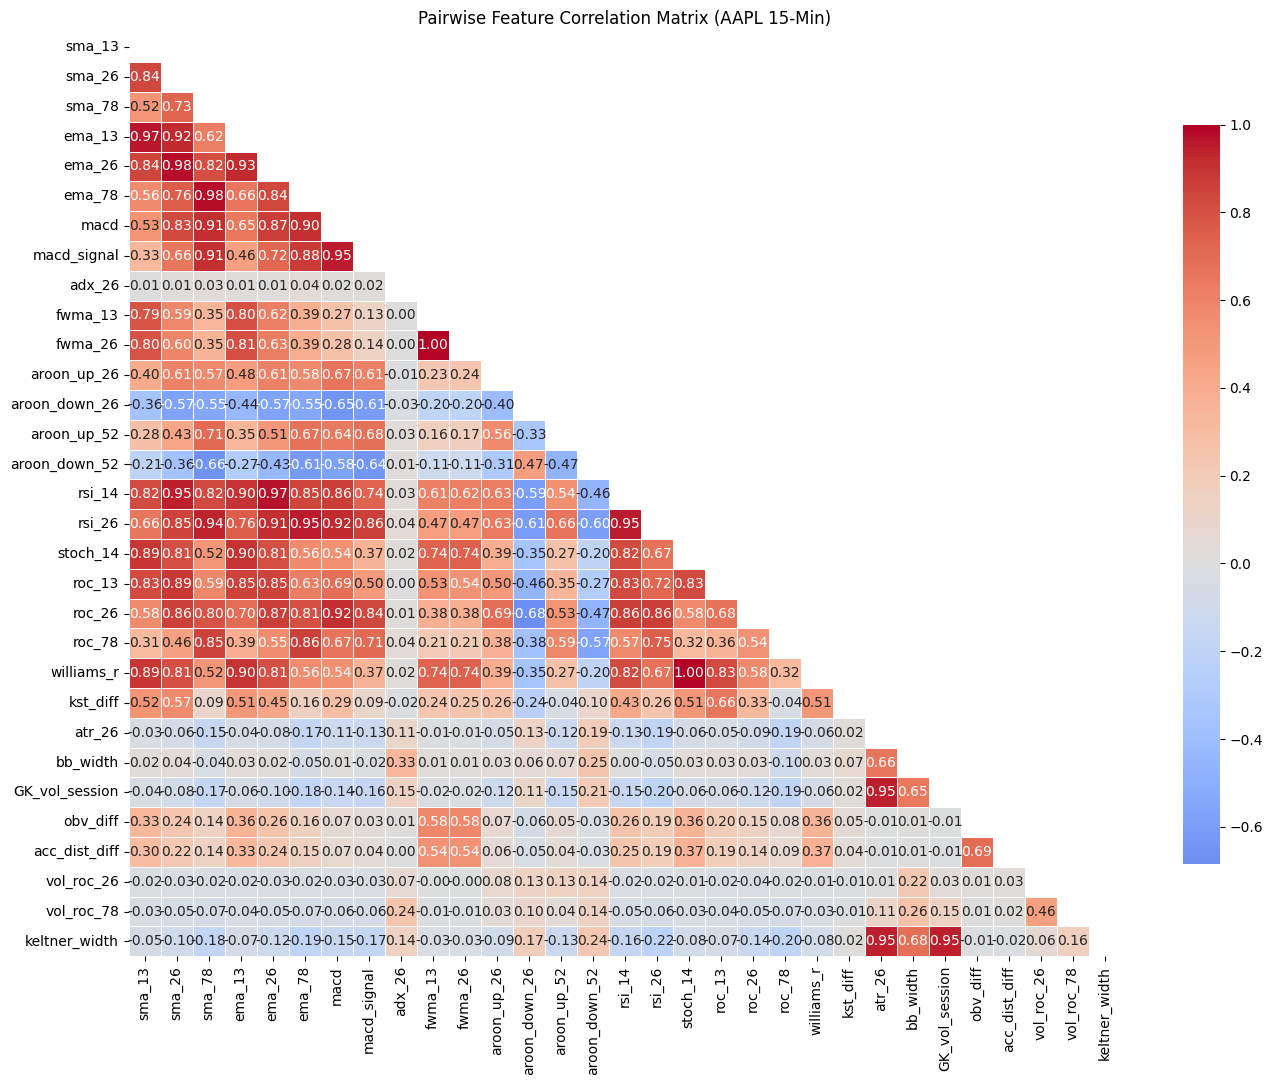

In [5]:
#Calculate the matrix
corr_matrix = X.corr(method='spearman')

#Create a mask for the upper triangle - to remove duplicate values and for a cleaner visual
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))

#Plot with annotations and mask
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,          # Shows the actual correlation numbers
    fmt=".2f",           # Rounds to 2 decimal places
    cmap="coolwarm", 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Pairwise Feature Correlation Matrix (AAPL 15-Min)")
plt.show()

In [6]:
#Take the absolute value of the matrix (to catch strong negative correlations too)
abs_corr = corr_matrix.abs()

#Select the upper triangle of the matrix 
upper_tri = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

#Stack the matrix into a Series and sort by the correlation value
sorted_pairs = upper_tri.stack().sort_values(ascending=False)

#Filter for pairs with a correlation higher than your threshold (e.g., 0.85)
threshold = 0.85
redundant_pairs = sorted_pairs[sorted_pairs > threshold]

print(f"Detected {len(redundant_pairs)} pairs with correlation > {threshold}:")
print(redundant_pairs)

Detected 40 pairs with correlation > 0.85:
stoch_14        williams_r        1.000000
fwma_13         fwma_26           0.999922
sma_78          ema_78            0.976722
sma_26          ema_26            0.975712
ema_26          rsi_14            0.972389
sma_13          ema_13            0.965794
ema_78          rsi_26            0.953113
macd            macd_signal       0.951988
rsi_14          rsi_26            0.947451
atr_26          keltner_width     0.947347
sma_26          rsi_14            0.946697
atr_26          GK_vol_session    0.945610
GK_vol_session  keltner_width     0.945481
sma_78          rsi_26            0.940751
ema_13          ema_26            0.927271
macd            rsi_26            0.921319
sma_26          ema_13            0.921129
macd            roc_26            0.915711
ema_26          rsi_26            0.911895
sma_78          macd              0.910941
                macd_signal       0.908388
ema_78          macd              0.902097
ema_13     

Calculating Mutual Information of the correlated features to pick one of the two as candidate features to feed into my LSTM model

In [ ]:
#Calculating the Mutual Information score between each feature and close price
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

#looping through all the correlated features to only keep the feature with the lower mutual information score 
to_drop = set()
results = []

for (feat_a, feat_b), correlation in redundant_pairs.items():

    # Skip a feature if its already been added to the 'to be dropped' list
    if feat_a in to_drop or feat_b in to_drop:
        continue
    
    mi_a = mi_results[feat_a]
    mi_b = mi_results[feat_b]
    
    if mi_a >= mi_b:
        winner, loser = feat_a, feat_b
        mi_win, mi_lose = mi_a, mi_b
    else:
        winner, loser = feat_b, feat_a
        mi_win, mi_lose = mi_b, mi_a
    
    to_drop.add(loser)
    
    results.append({
        'Feature A': feat_a,
        'Feature B': feat_b,
        'Correlation': round(correlation, 4),
        'MI_A': round(mi_a, 8),
        'MI_B': round(mi_b, 8),
        'Winner': winner,
        'Loser': loser
    })

#Looping through all 40 correlated pairs
features_in_pairs = set()
for (feat_a, feat_b), _ in redundant_pairs.items():
    features_in_pairs.add(feat_a)
    features_in_pairs.add(feat_b)

#Printing all features that weren't included in the correlated pairs to confirm they are added to the final feature list
never_compared = [f for f in X.columns if f not in features_in_pairs]

print(f"\nFeatures NEVER in any correlated pair: {len(never_compared)}")
print(never_compared)

print(f"\nFeatures that went through comparison: {len(features_in_pairs)}")
print(sorted(features_in_pairs))

#Displaying the results
comaparison_df = pd.DataFrame(results)
print(f"\n--- Removed {len(to_drop)} Redundant Features ---")
print(comaparison_df[['Feature A', 'MI_A', 'Feature B', 'MI_B', 'Correlation', 'Winner', 'Loser']])

#Printing the final features - from the comaprison dataframe and features that weren't included as part of the correlated pairs 
final_features = [f for f in X.columns if f not in to_drop]
print(f"\n{'='*60}")
print(f"Original Features: {len(X.columns)}")
print(f"Features Dropped: {len(to_drop)}")
print(f"Final Feature Count: {len(final_features)}")
print(f"\nFeatures Dropped: {sorted(to_drop)}")
print(f"\nFeatures Kept: {final_features}")


Features NEVER in any correlated pair: 11
['adx_26', 'aroon_up_26', 'aroon_down_26', 'aroon_up_52', 'aroon_down_52', 'kst_diff', 'bb_width', 'obv_diff', 'acc_dist_diff', 'vol_roc_26', 'vol_roc_78']

Features that went through comparison: 20
['GK_vol_session', 'atr_26', 'ema_13', 'ema_26', 'ema_78', 'fwma_13', 'fwma_26', 'keltner_width', 'macd', 'macd_signal', 'roc_13', 'roc_26', 'roc_78', 'rsi_14', 'rsi_26', 'sma_13', 'sma_26', 'sma_78', 'stoch_14', 'williams_r']

--- Removed 14 Redundant Features ---
   Feature A      MI_A       Feature B      MI_B  Correlation          Winner  \
0   stoch_14  0.031824      williams_r  0.031793       1.0000        stoch_14   
1    fwma_13  0.034973         fwma_26  0.032554       0.9999         fwma_13   
2     sma_78  0.252928          ema_78  0.240925       0.9767          sma_78   
3     sma_26  0.105855          ema_26  0.100240       0.9757          sma_26   
4     sma_13  0.057952          ema_13  0.059225       0.9658          ema_13   
5     

In [34]:
print("\n" + "="*60)
print("FINAL 17 FEATURES RANKED BY MUTUAL INFORMATION")
print("="*60)

#Ranking the final 17 features by highest to lowest Mutual Information
final_mi = mi_results[final_features].sort_values(ascending=False)

for i, (feat, score) in enumerate(final_mi.items(), 1):
    print(f"{i:2d}. {feat:20s} MI = {score:.6f}")


FINAL 17 FEATURES RANKED BY MUTUAL INFORMATION
 1. GK_vol_session       MI = 0.733196
 2. roc_78               MI = 0.340775
 3. obv_diff             MI = 0.309571
 4. bb_width             MI = 0.301810
 5. kst_diff             MI = 0.295743
 6. sma_78               MI = 0.252928
 7. adx_26               MI = 0.202213
 8. roc_26               MI = 0.159551
 9. acc_dist_diff        MI = 0.118063
10. fwma_13              MI = 0.034973
11. stoch_14             MI = 0.031824
12. vol_roc_78           MI = 0.026320
13. vol_roc_26           MI = 0.024009
14. aroon_down_26        MI = 0.016855
15. aroon_up_26          MI = 0.009726
16. aroon_down_52        MI = 0.007469
17. aroon_up_52          MI = 0.005062
